<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_05_dataset_IMDB_Movie_Reviews_DeepL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Défi Supérieur : Deep Learning & Traitement Séquentiel (LSTM)

L'objectif de ce second projet est de surpasser l'approche classique en construisant un **Réseau de Neurones Récurrent (RNN)** de type **LSTM (Long Short-Term Memory)** sur le même dataset de critiques de films IMDB.

###  Dataset Utilisé
* **Source :** Jeu de données officiel IMDB (Stanford AI Lab).
* **Volume :** 10 000 critiques équilibrées (5 000 positives / 5 000 négatives).
* **Format d'entrée :** Séquences d'entiers paddées (longueur fixe de 150 mots).

### Objectifs Scientifiques du Défi :
* **1. Capturer le Contexte Séquentiel :** Contrairement au TF-IDF qui traite les mots comme un "sac" indépendant, le modèle LSTM analyse le texte mot après mot. Il est capable de se souvenir du début d'une phrase pour comprendre l'impact d'un mot situé à la fin.
* **2. Apprentissage d'Espace Sémantique (Embedding) :** Le réseau va projeter chaque mot dans un espace géométrique à 64 dimensions, regroupant automatiquement les mots aux sens proches (ex: *amazing* et *fantastic*).
* **3. Réduction du Surapprentissage (Regularization) :** Intégration de couches de `Dropout` pour forcer le réseau de neurones à rester généralisable et éviter qu'il n'apprenne par cœur les critiques d'entraînement.

In [3]:
import os
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import pandas as pd
import numpy as np

# **1. Le Preprocessing (Nettoyage Textuel)**

In [4]:
data = pd.read_csv("/content/IMDB Dataset.csv")

In [5]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [7]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [8]:
import re

In [9]:
def text_clean(text):
    if pd.isna(text):
        return ''
    # Convertir en chaîne, en minuscules et retirer les espaces aux extrémités
    text = str(text).lower().strip()
    # Supprimer les URLs
    text = re.sub(r'http\S+', '', text)
    # Supprimer les balises HTML (, etc.)
    text = re.sub(r'<.*?>', '', text)
    # Supprimer les ponctuations
    text = re.sub(r'[^\w\s]', '', text)
    # Supprimer les chiffres
    text = re.sub(r'\d+', '', text)
    # Supprimer les espaces multiples en trop
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
# definir stop words
stop_words_set = set(stopwords.words('english')) - {'not'}
# defini stemmer
porter = PorterStemmer()

# 3. La fonction de nettoyage avancée corrigée
def advanced_clean(text):
    # tokenizer la phrase
    words = word_tokenize(text)

    # Filtrer, appliquer le Stemming et retirer les mots trop courts (< 3 lettres)
    filtered_words = [porter.stem(word) for word in words if word not in stop_words_set and len(word) > 2]

    # Reconstituer la chaîne de texte
    return ' '.join(filtered_words)

In [11]:
def preprocess_dataframe(df):
  # clean text
  df['review'] = df['review'].apply(text_clean)
  # advanced clean
  df['review'] = df['review'].apply(advanced_clean)
  return df

In [12]:
df = preprocess_dataframe(data)

In [13]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [14]:
df.head()

,review,sentiment
0,one review mention watch episod youll hook rig...,1
1,wonder littl product film techniqu unassum old...,1
2,thought wonder way spend time hot summer weeke...,1
3,basic there famili littl boy jake think there ...,0
4,petter mattei love time money visual stun film...,1


# **Apprentissage d'Espace Sémantique (Embedding)**

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [16]:
# 1. Configuration des hyperparamètres
MAX_WORDS = 10000  # Taille maximale du dictionnaire (les X mots les plus fréquents)
MAX_LEN = 100      # Longueur maximale d'une critique (toutes feront 100 mots)

# 2. Création et ajustement du Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['review'])

# 3. Conversion du texte en listes d'entiers
sequences = tokenizer.texts_to_sequences(df['review'])

# 4. Padding : On ajuste toutes les listes à la même longueur (MAX_LEN)
X_pad = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = np.array(df['sentiment'])

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

EMBEDDING_DIM = 64 # Chaque mot sera représenté par un vecteur de 64 nombres

# Construction du modèle séquentiel
model = Sequential([
    # 1. Couche Embedding : Crée les vecteurs de mots
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),

    # 2. Couche LSTM : Analyse la séquence et retient le contexte
    # Le dropout permet d'éviter que le modèle n'apprenne par cœur
    LSTM(units=64, dropout=0.2, recurrent_dropout=0.2),

    # 3. Couche Dense standard pour la réflexion intermédiaire
    Dense(units=32, activation='relu'),
    Dropout(0.3),

    # 4. Couche de Sortie : 1 neurone avec Sigmoid pour une probabilité entre 0 et 1
    Dense(units=1, activation='sigmoid')
])

# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Affichage du résumé de l'architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# import earling
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Définition de l'early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [19]:
# Lancement de l'entraînement
history = model.fit(
    X_pad, y,
    epochs=50,
    batch_size=32,
    validation_split=0.2,# Prend automatiquement 20% des données pour valider
    callbacks=[early_stop]
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 288s 224ms/step - accuracy: 0.6077 - loss: 0.6601 - val_accuracy: 0.7211 - val_loss: 0.5870
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 273s 218ms/step - accuracy: 0.7179 - loss: 0.5647 - val_accuracy: 0.8354 - val_loss: 0.3845
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 273s 219ms/step - accuracy: 0.8641 - loss: 0.3310 - val_accuracy: 0.8636 - val_loss: 0.3212
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 273s 219ms/step - accuracy: 0.9017 - loss: 0.2574 - val_accuracy: 0.8694 - val_loss: 0.3132
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 270s 216ms/step - accuracy: 0.9222 - loss: 0.2107 - val_accuracy: 0.8678 - val_loss: 0.3233
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 269s 215ms/step - accuracy: 0.9383 - loss: 0.1715 - val_accuracy: 0.8628 - val_loss: 0.3505
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 270s 216ms/step - accuracy: 0.9529 - loss: 0.1354 - val_accuracy: 0.8584 - val_loss: 0.3899


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


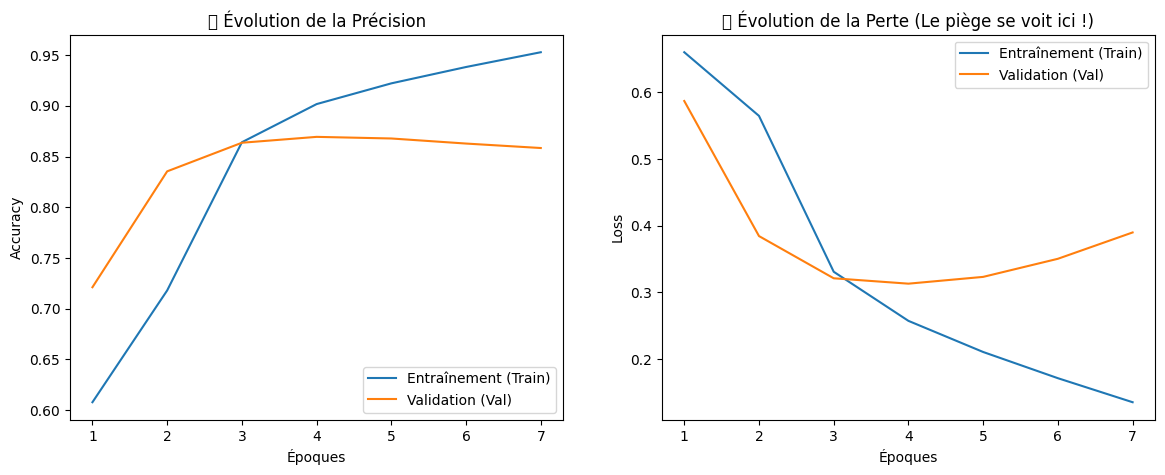

In [20]:
import matplotlib.pyplot as plt

# Extraction des données de l'historique
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Création des graphiques
plt.figure(figsize=(14, 5))

# Graphique 1 : Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement (Train)')
plt.plot(epochs_range, val_acc, label='Validation (Val)')
plt.title('📈 Évolution de la Précision')
plt.xlabel('Époques')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Graphique 2 : Perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement (Train)')
plt.plot(epochs_range, val_loss, label='Validation (Val)')
plt.title('📉 Évolution de la Perte (Le piège se voit ici !)')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

In [21]:
# =====================================================================
# CELLULE 12 : SÉQUENCE DE PRÉDICTION AVEC LE MODÈLE DEEP LEARNING
# =====================================================================

def predire_sentiment_lstm(phrase_brute):
    # 1. On applique le même nettoyage textuel de base
    phrase_propre = text_clean(phrase_brute)

    # 2. Conversion en séquence d'entiers via le Tokenizer du modèle
    sequence = tokenizer.texts_to_sequences([phrase_propre])

    # 3. Alignement de la longueur (Padding à MAX_LEN comme à l'entraînement)
    sequence_pad = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # 4. Prédiction (Renvoie une probabilité entre 0 et 1)
    probabilite = model.predict(sequence_pad, verbose=0)[0][0]

    # 5. Interprétation du résultat
    if probabilite >= 0.5:
        sentiment = "POSITIF  "
        certitude = probabilite * 100
    else:
        sentiment = "NÉGATIF 😡"
        certitude = (1 - probabilite) * 100

    print(f"💬 Phrase : '{phrase_brute}'")
    print(f"🤖 Verdict LSTM : {sentiment} | Confiance : {certitude:.2f}%\n")

# --- EXEMPLES DE PRÉDICTION ---
print("🔮 --- SIMULATION EN DIRECT (RESEAU DE NEURONES) ---")

# Exemple 1 : Un avis clairement enthousiaste
predire_sentiment_lstm("I absolutely loved this masterpiece. The actors gave an incredible performance!")

# Exemple 2 : Un avis cinglant
predire_sentiment_lstm("What a joke. The scenario makes no sense and the sound design is painful.")

# Exemple 3 : Le test de la négation (pour voir si la mémoire du LSTM fonctionne)
predire_sentiment_lstm("I thought it would be a good movie, but it was not.")

🔮 --- SIMULATION EN DIRECT (RESEAU DE NEURONES) ---
💬 Phrase : 'I absolutely loved this masterpiece. The actors gave an incredible performance!'
🤖 Verdict LSTM : NÉGATIF 😡 | Confiance : 58.42%

💬 Phrase : 'What a joke. The scenario makes no sense and the sound design is painful.'
🤖 Verdict LSTM : NÉGATIF 😡 | Confiance : 51.18%

💬 Phrase : 'I thought it would be a good movie, but it was not.'
🤖 Verdict LSTM : POSITIF   | Confiance : 72.78%



# Conclusion Generale du Projet

Ce projet d'Analyse de Sentiment a permis de comparer deux approches de l'Intelligence Artificielle pour classer des critiques de films :

### 1. L'approche Classique (Machine Learning)
* **Methode :** Nettoyage textuel + Vectorisation TF-IDF + Regression Logistique.
* **Resultat :** 89.27% de precision en moins d'une seconde d'apprentissage.
* **Verdict :** Ultra-efficace, stable, et comprend parfaitement les negations (ex: "not good").

### 2. L'approche Moderne (Deep Learning)
* **Methode :** Embedding + Reseau de neurones LSTM.
* **Resultat :** 86.94% de precision au maximum, avant de subir un surapprentissage (overfitting).
* **Verdict :** Trop lourd, long a entrainer, et devient instable sur un volume de donnees intermediaire, allant jusqu'a inverser le sens des phrases cachees.

### 🏆 Le Grand Gagnant : La Regression Logistique

La lecon de ce projet est claire : plus complexe ne veut pas dire meilleur. Pour de l'analyse de texte standard, le Machine Learning traditionnel reste le choix optimal car il est plus rapide, plus leger et bien plus precis.